Importing libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt


Generating Dataset

In [5]:
np.random.seed(42)
n=300
df=pd.DataFrame({
    'student_id': range(1,n+1),
    'age': np.random.randint(17,25,n),
    'gender': np.random.choice(['Male','Female'],n,p=[0.6,0.4]),
    'course': np.random.choice(['Science','Commerce','Arts','Engineering'],n),
    'study_hours': np.round(np.random.normal(5,2,n).clip(0,14),1),
    'sleep_hours': np.round(np.random.normal(7,1.2,n).clip(4,10),1),
    'stress_level': np.random.choice(['Low','Medium','High'],n,p=[0.3,0.45,0.25]),
    'attendance_pct': np.round(np.random.normal(78,12,n).clip(40,100),1),
    'score': np.round(np.random.normal(65,15,n).clip(20,100),1),
})
df['passed']=(df['score']>=50).map({True: 'Pass', False: 'Fail'})

df.to_csv('student.csv', index=False)
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (300, 10)


,student_id,age,gender,course,study_hours,sleep_hours,stress_level,attendance_pct,score,passed
0,1,23,Female,Science,3.9,5.9,Low,79.0,29.6,Fail
1,2,20,Male,Engineering,3.4,10.0,Low,76.8,49.9,Fail
2,3,21,Male,Commerce,4.8,7.6,High,89.0,74.3,Pass
3,4,23,Male,Arts,2.9,7.2,Low,74.5,95.9,Pass
4,5,19,Female,Arts,3.9,6.0,High,81.2,65.3,Pass


Basic info

In [6]:
print('--- dtypes ---')
print(df.dtypes)
print('\n--- missing values ---')
print(df.isnull().sum())

--- dtypes ---
student_id          int64
age                 int64
gender             object
course             object
study_hours       float64
sleep_hours       float64
stress_level       object
attendance_pct    float64
score             float64
passed             object
dtype: object

--- missing values ---
student_id        0
age               0
gender            0
course            0
study_hours       0
sleep_hours       0
stress_level      0
attendance_pct    0
score             0
passed            0
dtype: int64


In [7]:
df.describe().round(2)

,student_id,age,study_hours,sleep_hours,attendance_pct,score
count,300.00,300.00,300.00,300.00,300.00,300.00
mean,150.50,20.51,4.85,7.21,78.50,65.71
std,86.75,2.29,2.00,1.14,11.71,14.21
min,1.00,17.00,0.00,4.10,42.90,24.50
25%,75.75,19.00,3.50,6.40,70.70,55.88
50%,150.50,20.00,4.80,7.20,78.35,65.20
75%,225.25,23.00,6.20,7.90,86.62,76.10
max,300.00,24.00,11.20,10.00,100.00,100.00


NumPy Operations

In [8]:
score=df['score'].to_numpy()
study=df['study_hours'].to_numpy()
sleep=df['sleep_hours'].to_numpy()
print(f' Mean : {np.mean(score):.2f}')
print(f' Median : {np.median(score):.2f}')
print(f' Std : {np.std(score):.2f}')
print(f' Min/Max : {np.min(score):.1f}/ {np.max(score):.1f}')

 Mean : 65.71
 Median : 65.20
 Std : 14.19
 Min/Max : 24.5/ 100.0


In [10]:
p25,p50,p75=np.percentile(score,[25,50,75])
print(f'Percentile 25th:{p25} 50th:{p50} 75th:{p75}')

corr=np.corrcoef(study,score)[0,1]
print(f'\nCorrelation (study_hours vs score): {corr:.4f}')

Percentile 25th:55.875 50th:65.19999999999999 75th:76.1

Correlation (study_hours vs score): -0.0207


Pandas Operations

In [11]:
print('Average score per course: ')
print(df.groupby('course')['score'].mean().round(2).to_string())

Average score per course: 
course
Arts           65.45
Commerce       64.83
Engineering    66.00
Science        66.46


In [13]:
print('Avg study hours by stress level:')
print(df.groupby('stress_level')['study_hours'].mean().round(2).to_string())
print('\nPass / Fail counts:')
print(df['passed'].value_counts().to_string())

Avg study hours by stress level:
stress_level
High      5.00
Low       4.95
Medium    4.72

Pass / Fail counts:
passed
Pass    262
Fail     38


In [15]:
pivote=df.pivot_table(values='score',index='course',columns='stress_level',aggfunc='mean')
pivote.round(2)

stress_level,High,Low,Medium
course,,,
Arts,64.44,69.23,63.37
Commerce,65.91,60.41,67.37
Engineering,71.53,63.86,63.84
Science,67.21,67.49,65.72


In [16]:
df['efficiency'] = (df['score'] / df['study_hours'].replace(0, np.nan)).round(2)

print('Top 5 most efficient students:')
df.nlargest(5, 'efficiency')[['student_id', 'study_hours', 'score', 'efficiency']]

Top 5 most efficient students:


,student_id,study_hours,score,efficiency
90,91,0.1,47.3,473.00
121,122,0.6,63.6,106.00
17,18,0.4,41.6,104.00
254,255,0.8,79.5,99.38
112,113,0.9,75.1,83.44


In [17]:
numeric_cols = ['age', 'study_hours', 'sleep_hours', 'attendance_pct', 'score']
df[numeric_cols].corr().round(3)

,age,study_hours,sleep_hours,attendance_pct,score
age,1.000,0.064,0.002,-0.069,0.051
study_hours,0.064,1.000,-0.041,0.030,-0.021
sleep_hours,0.002,-0.041,1.000,0.052,0.015
attendance_pct,-0.069,0.030,0.052,1.000,0.005
score,0.051,-0.021,0.015,0.005,1.000


Matplotlib Visualisations

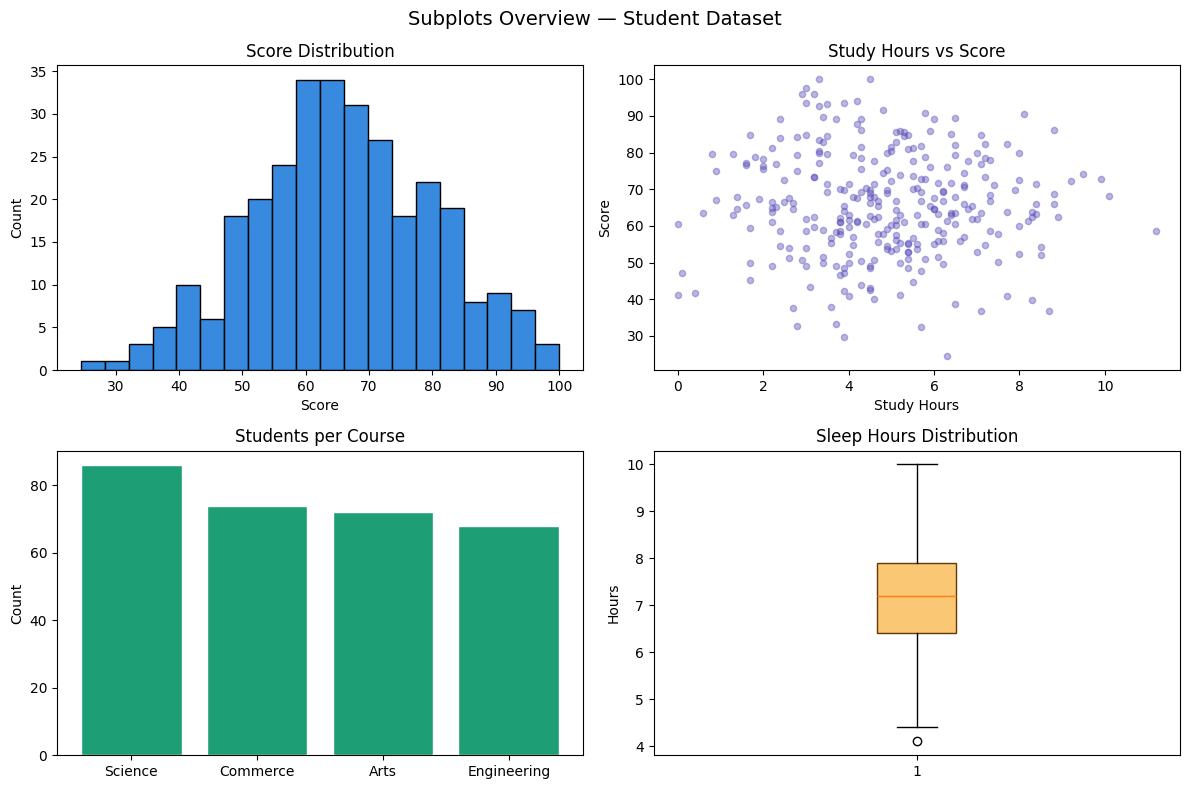

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Subplots Overview — Student Dataset', fontsize=14)

# top-left: histogram
axes[0,0].hist(df['score'], bins=20, color='#378ADD', edgecolor='black')
axes[0,0].set_title('Score Distribution')
axes[0,0].set_xlabel('Score'); axes[0,0].set_ylabel('Count')

# top-right: scatter
axes[0,1].scatter(df['study_hours'], df['score'], alpha=0.4, color='#534AB7', s=20)
axes[0,1].set_title('Study Hours vs Score')
axes[0,1].set_xlabel('Study Hours'); axes[0,1].set_ylabel('Score')

# bottom-left: bar
counts = df['course'].value_counts()
axes[1,0].bar(counts.index, counts.values, color='#1D9E75', edgecolor='white')
axes[1,0].set_title('Students per Course')
axes[1,0].set_ylabel('Count')

# bottom-right: boxplot
axes[1,1].boxplot(df['sleep_hours'], patch_artist=True,
                  boxprops=dict(facecolor='#FAC775', color='#633806'))
axes[1,1].set_title('Sleep Hours Distribution')
axes[1,1].set_ylabel('Hours')

plt.tight_layout()
plt.show()